## 1.1 Contents<a id='1.1_Contents'></a>
* [1. User Retention Predictive Modeling](#1_User_Retention_Predictive_Modeling)
  * [1.1 Contents](#1.1_Contents)
  * [1.2 Problem Statement](#1.2_Problem_Statement)
  * [1.3 Imports](#1.3_Imports)
  * [1.4 Load the Data](#1.4_Load_the_Data)
  * [1.5 Data Wrangling](#1.5_Data_Wrangling)
  * [1.6 Exploratory Data Analysis](#1.6_Exploratory_Data_Analysis)
  * [1.7 Modeling](#1.7_Modeling)
    * [1.7.1 Logistic Regression Model](#1.7.1_Logistic_Regression_Model)
    * [1.7.2 Random Forest Model](#1.7.2_Random_Forest_Model)
  * [1.8 Key Insights](#1.8_Key_Insights)
  * [1.9 Recommendations](#1.9_Recommendations)
  * [1.10 Limitations & Next Steps](#1.10_Limitations_&_Next_Steps)

## 1.2 Problem Statement<a id='1.2_Problem_Statement'></a>

Ultimate Technologies Inc. is a transportation network company that has disrupted the taxi and logistics industry and is considered to be one of the best companies in this sector.
#### They would like to understand what it takes to predict and improve its long term rider retention. 

A data set has been provided for this exercise to help understand what factors are the best predictors for retention, and offer suggestions to operationalize those insights to help Ultimate.

## 1.3 Imports<a id='1.3_Imports'></a>

Let's import the necessary packages to perform the analysis.

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
import os

## 1.4 Load the Data<a id='1.4_Load_the_Data'></a>

Lets load the json data file into pandas dataframe.

In [2]:
ud = pd.read_json('ultimate_data_challenge.json')

In [3]:
#Quick Dataframe Inspection to check data got loaded properly
ud.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


## 1.5 Data Wrangling<a id='1.5_Data_Wrangling'></a>

In this section, we will do data inspection, cleaning, any restructuring for the next steps of Exploratory Data Analysis and Modeling.

In [4]:
ud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


The data contains 50000 entries and there are some nulls in avg_rating_of_driver, phone & avg_rating_by_driver columns.  
signup_date and last_trip_date contain dates but are currently stored as objects. Lets first convert them to dates.

In [5]:
ud['signup_date']=pd.to_datetime(ud['signup_date'])
ud['last_trip_date']=pd.to_datetime(ud['last_trip_date'])

In [6]:
#lets check whether they got converted properly
ud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    50000 non-null  object        
 1   trips_in_first_30_days  50000 non-null  int64         
 2   signup_date             50000 non-null  datetime64[ns]
 3   avg_rating_of_driver    41878 non-null  float64       
 4   avg_surge               50000 non-null  float64       
 5   last_trip_date          50000 non-null  datetime64[ns]
 6   phone                   49604 non-null  object        
 7   surge_pct               50000 non-null  float64       
 8   ultimate_black_user     50000 non-null  bool          
 9   weekday_pct             50000 non-null  float64       
 10  avg_dist                50000 non-null  float64       
 11  avg_rating_by_driver    49799 non-null  float64       
dtypes: bool(1), datetime64[ns](2), float64(6), int

In [7]:
ud.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


Dates look good. Lets inspect and remove any duplicate records.

In [8]:
ud.duplicated().sum()

np.int64(8)

In [9]:
ud[ud.duplicated()]

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
2608,Astapor,1,2014-01-18,5.0,1.0,2014-01-19,iPhone,0.0,True,0.0,6.25,5.0
18057,Astapor,1,2014-01-11,5.0,1.0,2014-01-11,iPhone,0.0,True,0.0,2.33,5.0
29601,Winterfell,1,2014-01-01,NaN,1.0,2014-01-02,Android,0.0,False,100.0,8.08,5.0
34641,Winterfell,1,2014-01-18,NaN,1.0,2014-01-19,iPhone,0.0,True,0.0,1.44,5.0
36627,Winterfell,1,2014-01-18,5.0,1.0,2014-01-19,Android,0.0,False,0.0,3.54,5.0
39601,Winterfell,1,2014-01-10,5.0,1.0,2014-01-11,Android,0.0,False,100.0,0.00,5.0
42025,Winterfell,1,2014-01-18,NaN,1.0,2014-01-19,Android,0.0,False,0.0,0.01,5.0
45416,Astapor,1,2014-01-20,5.0,1.0,2014-01-20,iPhone,0.0,False,100.0,3.06,5.0


There are 8 duplicate records. However, it is difficult to confirm that they belong to the same user since we are not given the unique user ids. In this case, since they represent a very tiny fraction of data, we will drop them as a precaution.

In [10]:
ud = ud.drop_duplicates()

In [11]:
ud.duplicated().sum()

np.int64(0)

Next, lets handle nulls for avg_rating_of_driver and avg_rating_by_driver. Lets inspect missing values.

In [12]:
ud[ud['avg_rating_by_driver'].isna()]

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
90,Winterfell,1,2014-01-10,5.0,1.0,2014-02-09,iPhone,0.0,False,0.0,6.28,NaN
274,Astapor,1,2014-01-25,2.0,4.0,2014-02-09,iPhone,100.0,False,0.0,6.00,NaN
277,Winterfell,1,2014-01-25,NaN,1.0,2014-01-26,iPhone,0.0,False,0.0,1.82,NaN
536,Winterfell,1,2014-01-18,5.0,1.0,2014-02-08,Android,0.0,False,100.0,1.41,NaN
857,Winterfell,0,2014-01-11,4.0,1.0,2014-03-16,iPhone,0.0,False,0.0,0.42,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
49249,King's Landing,0,2014-01-14,5.0,1.0,2014-06-19,iPhone,0.0,True,100.0,4.60,NaN
49376,Astapor,1,2014-01-20,4.0,1.0,2014-01-24,iPhone,0.0,False,100.0,3.01,NaN
49504,Winterfell,2,2014-01-24,5.0,1.0,2014-01-25,Android,0.0,False,100.0,0.75,NaN
49599,King's Landing,1,2014-01-14,5.0,1.0,2014-02-08,iPhone,0.0,False,100.0,2.48,NaN


Since, this field has <0.5% missing values we will impute it using median and add a missing flag feature for appropriate handling by linear models.

In [13]:
ud['avg_rating_by_driver_missing']=ud['avg_rating_by_driver'].isna()
ud['avg_rating_by_driver'] = ud['avg_rating_by_driver'].fillna(ud['avg_rating_by_driver'].median())

In [14]:
ud[ud['avg_rating_of_driver'].isna()]

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,avg_rating_by_driver_missing
6,Astapor,1,2014-01-24,NaN,1.0,2014-01-25,Android,0.0,False,100.0,3.95,4.0,False
9,Winterfell,1,2014-01-03,NaN,1.0,2014-01-05,Android,0.0,False,0.0,2.37,5.0,False
12,Winterfell,1,2014-01-15,NaN,1.0,2014-03-12,iPhone,0.0,False,100.0,20.29,5.0,False
14,Astapor,1,2014-01-27,NaN,1.0,2014-01-28,Android,0.0,False,100.0,26.01,5.0,False
15,Winterfell,1,2014-01-15,NaN,1.0,2014-01-16,Android,0.0,True,100.0,13.20,5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49984,Winterfell,1,2014-01-26,NaN,1.0,2014-01-26,Android,0.0,False,0.0,3.50,5.0,False
49985,Astapor,1,2014-01-26,NaN,1.0,2014-02-25,Android,0.0,False,100.0,1.38,5.0,False
49989,Winterfell,1,2014-01-24,NaN,1.0,2014-01-31,iPhone,0.0,False,100.0,0.00,5.0,False
49996,Astapor,1,2014-01-24,NaN,1.0,2014-01-25,iPhone,0.0,False,0.0,0.00,4.0,False


In [15]:
ud[ud['avg_rating_of_driver'].isna()].groupby('last_trip_date').count().sort_values(by = 'last_trip_date')

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,avg_rating_by_driver_missing
last_trip_date,,,,,,,,,,,,
2014-01-01,57,57,57,0,57,57,57,57,57,57,57,57
2014-01-02,53,53,53,0,53,53,53,53,53,53,53,53
2014-01-03,41,41,41,0,41,40,41,41,41,41,41,41
2014-01-04,50,50,50,0,50,49,50,50,50,50,50,50
2014-01-05,85,85,85,0,85,83,85,85,85,85,85,85
...,...,...,...,...,...,...,...,...,...,...,...,...
2014-06-27,80,80,80,0,80,79,80,80,80,80,80,80
2014-06-28,87,87,87,0,87,87,87,87,87,87,87,87
2014-06-29,96,96,96,0,96,94,96,96,96,96,96,96


~16% values are missing for avg_rating_of_driver. The last trip date is also has a wide range for these missing values. This most certainly points to low user engagement or early churn. We will add a missing values flag in this case as well. We will impute missing values using median and segment it based on city for cleaner handling by the models.

In [16]:
ud['avg_rating_of_driver_missing']=ud['avg_rating_of_driver'].isna()
ud['avg_rating_of_driver'] = ud.groupby('city')['avg_rating_of_driver'].transform(lambda x : x.fillna(x.median()))

Let us check the dataset for missing values again.

In [17]:
ud.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49992 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   city                          49992 non-null  object        
 1   trips_in_first_30_days        49992 non-null  int64         
 2   signup_date                   49992 non-null  datetime64[ns]
 3   avg_rating_of_driver          49992 non-null  float64       
 4   avg_surge                     49992 non-null  float64       
 5   last_trip_date                49992 non-null  datetime64[ns]
 6   phone                         49596 non-null  object        
 7   surge_pct                     49992 non-null  float64       
 8   ultimate_black_user           49992 non-null  bool          
 9   weekday_pct                   49992 non-null  float64       
 10  avg_dist                      49992 non-null  float64       
 11  avg_rating_by_driver          499

Great! We just have phone missing which is a categorical feature so we do not have to worry about null values there as it is not one of the primary features.

We are not given a column for our target variable of user retained or not?

In [18]:
#lets create the target binary feature or user retained or not (should be active in last 30 days based on the max date provided in the dataset)
max_date = ud['last_trip_date'].max()
ud['retained'] = (max_date - ud['last_trip_date']).dt.days <= 30

In [19]:
#proportion of retained customers
ud['retained'].mean()

np.float64(0.3761401824291887)

~38% retention rate can be seen in this dataset.

In [20]:
ud.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49992 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   city                          49992 non-null  object        
 1   trips_in_first_30_days        49992 non-null  int64         
 2   signup_date                   49992 non-null  datetime64[ns]
 3   avg_rating_of_driver          49992 non-null  float64       
 4   avg_surge                     49992 non-null  float64       
 5   last_trip_date                49992 non-null  datetime64[ns]
 6   phone                         49596 non-null  object        
 7   surge_pct                     49992 non-null  float64       
 8   ultimate_black_user           49992 non-null  bool          
 9   weekday_pct                   49992 non-null  float64       
 10  avg_dist                      49992 non-null  float64       
 11  avg_rating_by_driver          499

Lets look at the basic stats for our dataset below.

In [21]:
ud.describe(include = 'all')

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,avg_rating_by_driver_missing,avg_rating_of_driver_missing,retained
count,49992,49992.000000,49992,49992.000000,49992.000000,49992,49596,49992.000000,49992,49992.000000,49992.00000,49992.000000,49992,49992,49992
unique,3,NaN,NaN,NaN,NaN,NaN,2,NaN,2,NaN,NaN,NaN,2,2,2
top,Winterfell,NaN,NaN,NaN,NaN,NaN,iPhone,NaN,False,NaN,NaN,NaN,False,False,False
freq,23331,NaN,NaN,NaN,NaN,NaN,34578,NaN,31141,NaN,NaN,NaN,49791,41873,31188
mean,NaN,2.278405,2014-01-16 13:04:52.078732800,4.650430,1.074776,2014-04-19 08:23:49.284685568,NaN,8.850952,NaN,60.929833,5.79726,4.779015,NaN,NaN,NaN
min,NaN,0.000000,2014-01-01 00:00:00,1.000000,1.000000,2014-01-01 00:00:00,NaN,0.000000,NaN,0.000000,0.00000,1.000000,NaN,NaN,NaN
25%,NaN,0.000000,2014-01-09 00:00:00,4.500000,1.000000,2014-02-14 00:00:00,NaN,0.000000,NaN,33.300000,2.42000,4.700000,NaN,NaN,NaN
50%,NaN,1.000000,2014-01-17 00:00:00,4.900000,1.000000,2014-05-08 00:00:00,NaN,0.000000,NaN,66.700000,3.88000,5.000000,NaN,NaN,NaN
75%,NaN,3.000000,2014-01-24 00:00:00,5.000000,1.050000,2014-06-18 00:00:00,NaN,8.600000,NaN,100.000000,6.94000,5.000000,NaN,NaN,NaN
max,NaN,125.000000,2014-01-31 00:00:00,5.000000,8.000000,2014-07-01 00:00:00,NaN,100.000000,NaN,100.000000,160.96000,5.000000,NaN,NaN,NaN


## 1.6 Exploratory Data Analysis<a id='1.6_Exploratory_Data_Analysis'></a>

As we saw during data wrangling, Ultimate's current retention rate is ~38%.Let us dive deeper into the categorical and numerical feature analysis

### 1.4.1 Categorical Features<a id='1.4.1_Categorical_Features?'></a>

In [30]:
#Lets check retention rate by city
ud.groupby('city')['retained'].mean().sort_values(ascending=False)

city
King's Landing    0.628134
Winterfell        0.352021
Astapor           0.255762
Name: retained, dtype: float64

It looks like King's Landing has maximum user retention and Astapor has the least retention.

In [34]:
#Lets check retention rate by phone type
ud.groupby('phone')['retained'].mean().sort_values(ascending=False)

phone
iPhone     0.448985
Android    0.209482
Name: retained, dtype: float64

iPhone user have more than double the retention rate compared to android users.

### 1.4.2 Numerical Features<a id='1.4.2_Numerical_Features'></a>

In [35]:
#checking avg. trips retained vs. churned users took in first 30 days
ud.groupby('retained')['trips_in_first_30_days'].mean().sort_values(ascending=False)

retained
True     3.306318
False    1.658651
Name: trips_in_first_30_days, dtype: float64

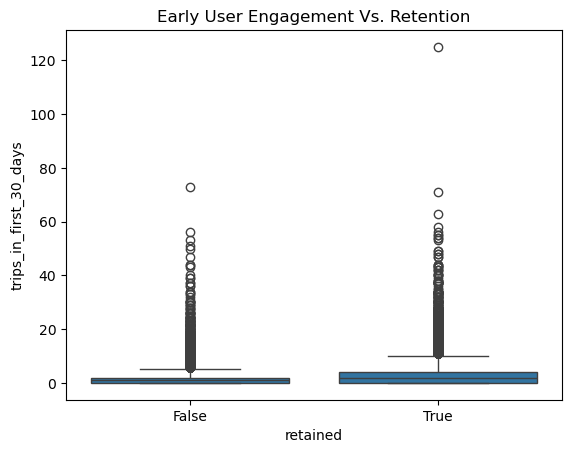

In [41]:
#lets look at the box plot for user retention vs. trips taken in first 30 days
sns.boxplot(x = 'retained', y = 'trips_in_first_30_days', data = ud)
plt.title("Early User Engagement Vs. Retention")
plt.show()

High First 30 days trips activity seems to be strongly associated with retention rate.

In [37]:
#checking avg. trip distance traveled for trips by retained vs. churned users in first 30 days
ud.groupby('retained')['avg_dist'].mean().sort_values(ascending=False)

retained
False    6.208739
True     5.114788
Name: avg_dist, dtype: float64

It looks like users with shorter distance trips on average tend to stay with Ultimate.

In [39]:
#checking avg. surge percent for retained vs. churned users
ud.groupby('retained')['surge_pct'].mean().sort_values(ascending=False)

retained
True     9.152797
False    8.668962
Name: surge_pct, dtype: float64

It looks like retained users have a slightly higher surge percent. This could indicate more frequent usage and heavier demand in the retained user population.

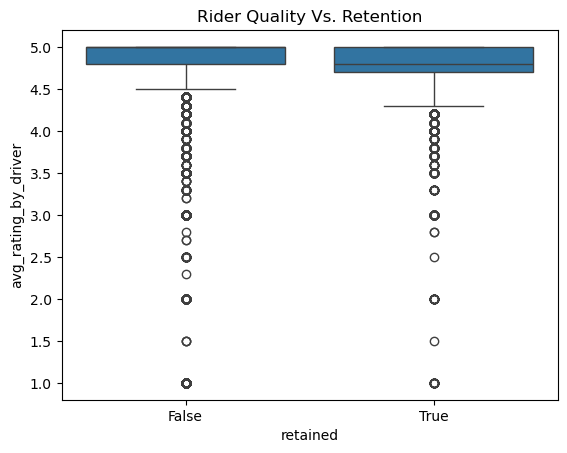

In [42]:
#lets look at the box plot for user retention vs. avg. rating of rider by driverd
sns.boxplot(x = 'retained', y = 'avg_rating_by_driver', data = ud)
plt.title("Rider Quality Vs. Retention")
plt.show()

Most of the users retained or not have a high average rating between 4.7 to 5, although the median for the retained group seems to be slightly higher which tells us that rider quality is weakly related with user retention.

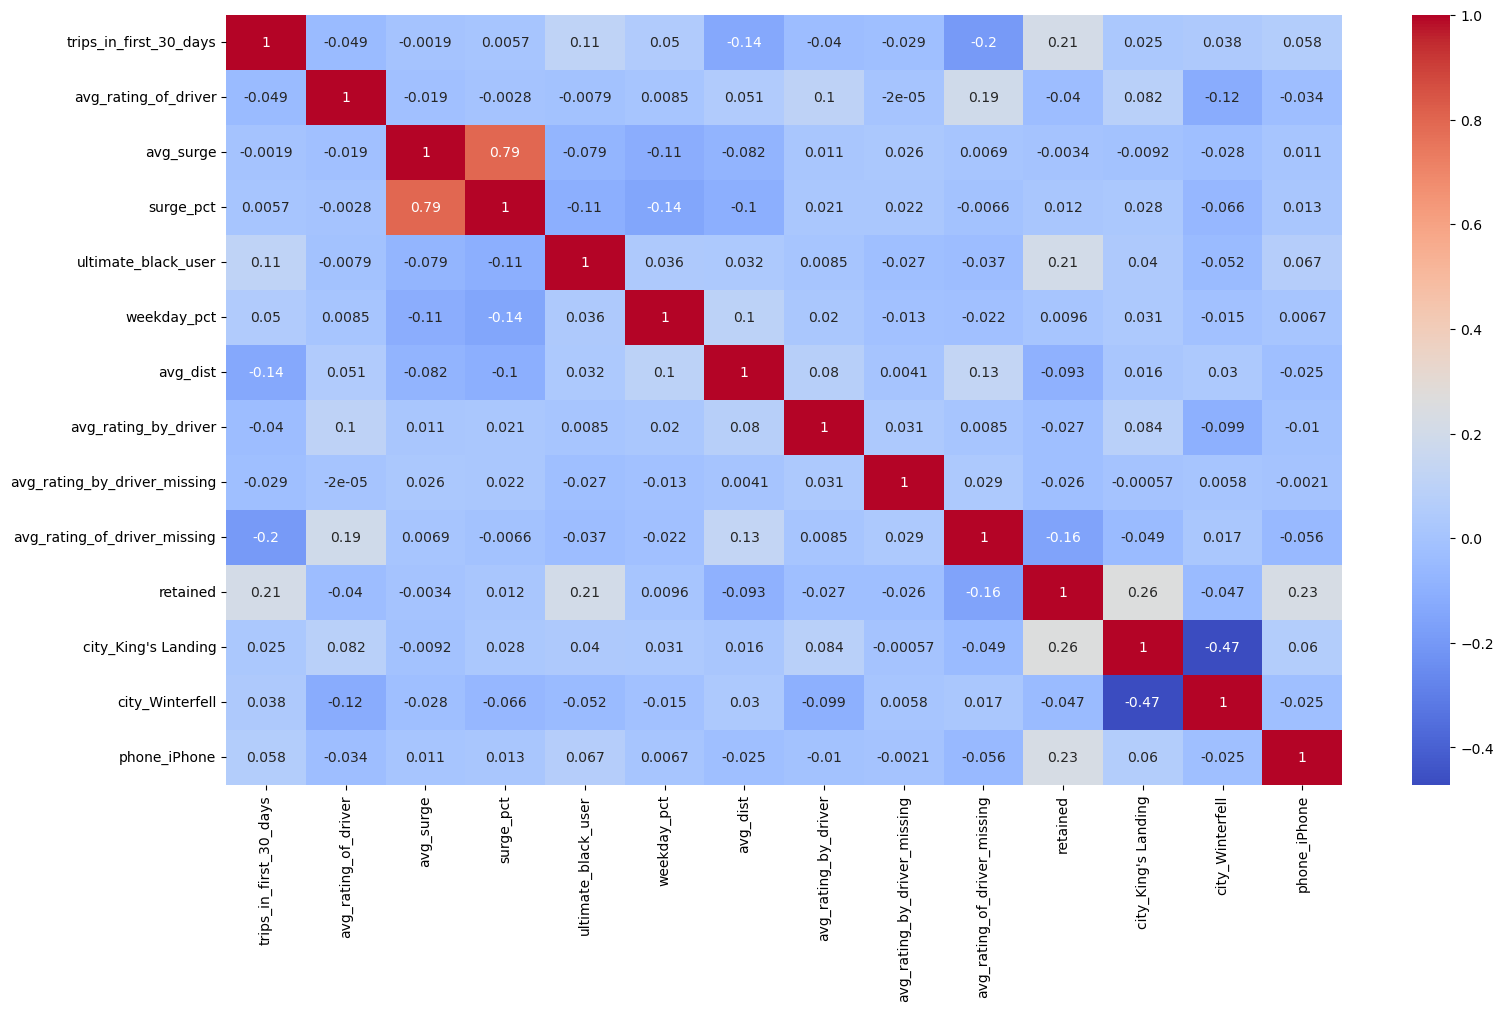

In [51]:
#Let us look at the feature correlations next
#we will encode the categorical features for this exercise as well as modeling using pd.getdummies() function and also drop date fields
ud_model = ud.drop(['signup_date','last_trip_date'], axis = 1)
ud_model = pd.get_dummies(ud_model, columns = ['city','phone'], drop_first = True)
plt.figure(figsize=(18,10))
sns.heatmap(ud_model.corr(), cmap = 'coolwarm', annot = True)
plt.show()

Based on the correlation heatmap above, it looks like we do not have very strong correlations of any features with user retention.  
However, positive correlations of user retention can be seen with the following features 
1. trips in first 30 days,  
2. ultimate black user,  
3. iphone users and   
4. King's landing city.

Let us model for user retention next.

## 1.7 Modeling<a id='1.7_Modeling'></a>

We will be using two model stated below for this project.

1. Logistic Regression Model - For Better Interpretablity to derive business insights
2. Random Forest Model - To handle any non linear relationships more effectively that could lead to better predictive power.

In [55]:
#Lets first create the train/test sets (80/20 split) as they will be the same for both models
X = ud_model.drop(['retained'], axis =1)
y = ud_model['retained']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

### 1.7.1 Logistic Regression Model<a id='1.7.1_ Logistic_Regression_Model'></a>

In [57]:
#Build the pipeline and fit the model
log_model = Pipeline([
                      ('scaler',StandardScaler()),
                      ('model', LogisticRegression(max_iter = 1000))
                    ])
log_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [74]:
#Lets look at predictions on test set and model performance
pred = log_model.predict(X_test)
prob = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression Model Performance")
print(f"-"*55)
print(classification_report(y_test, pred))
print(f"ROC_AUC_Score: {round(roc_auc_score(y_test, prob),4)}")

Logistic Regression Model Performance
-------------------------------------------------------
              precision    recall  f1-score   support

       False       0.74      0.86      0.79      6238
        True       0.68      0.50      0.58      3761

    accuracy                           0.72      9999
   macro avg       0.71      0.68      0.69      9999
weighted avg       0.72      0.72      0.71      9999

ROC_AUC_Score: 0.7649


Interpretation of Logistic Regression Model Performance

##### Accuracy (72%) - 
This model correctly classifies 7 in 10 riders. However, accuracy alone cannot be relied upon in this case since it is an imbalanced dataset.(~37% retention & 63% churned)  
##### Not Retained (False, Precision : 74%, Recall : 86%) - 
This model shows good performance 86% recall for correctly classifying churned customers and is reasonably precise for predicting churn.  
##### Retained (True, Precision : 68%, Recall : 50%) - 
Retained class is misclassified half the time (50% recall) and when it does predict retention, it is correct 68% of the time.  
##### ROC AUC Score (0.76) - 
This is a decent score where the model has a signal for making perdictions. However, there is a good percentage of customers that look similar to the model with the available features.<p>

Logistic Regression model gives an interpretable baseline with reasonable overall discrimination (AUC ~0.76), but its main weakness is under-identifying retained riders (low recall on the True class).  Hence we would like to compare it against a more flexible model (e.g., Random Forest), which can pick up non-linear/interaction effects and lift recall on the retained customers without sacrificing much precision.

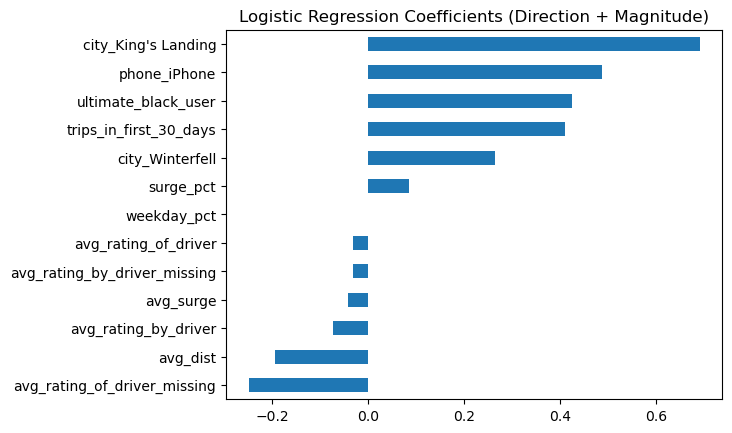

In [90]:
#Lets look at Feature Importance
coef = pd.Series(log_model.named_steps['model'].coef_[0], index = X.columns)
coef.sort_values().plot(kind = 'barh')
plt.title("Logistic Regression Coefficients (Direction + Magnitude)")
plt.show()

##### Positive predictors (increase odds of retention):
•	city_King's Landing (~ 0.70) - It looks like King's Landing users have substantially higher odds of retention, consistent with the ~ 63% raw retention rate we saw there earlier.  
•	phone_iPhone (~ 0.50) -  iPhone users have higher retention than Android users.  
•	ultimate_black_user (~ 0.43) & trips_in_first_30_days (~ 0.40) - Using Ultimate Black and taking more trips early on are both tied to higher retention.  
•	city_Winterfell (~ 0.27) — a smaller positive effect vs. baseline, but still meaningfully positive.  
•	surge_pct (~ 0.08) — very little positive effect; riders exposed to more surge pricing have slightly more retention which does not make immediate sense. This might just be reflecting more frequent users naturally encountering surge more often.  
##### No Effect
•	weekday_pct — Contributes almost nothing towards retention.  
##### Negative predictors (decrease odds of retention):
•	avg_rating_of_driver, avg_rating_by_driver_missing, avg_surge, avg_rating_by_driver - all small negative effects, close to zero.  
•	avg_dist (~ -0.20) - a more notable negative effect: riders who take longer trips on average are somewhat less likely to be retained.  
•	avg_rating_of_driver_missing (~-0.22) - the largest negative coefficient. This means the rider had fewer trips and they never rated a driver. This indicates that low early engagement predicts churn.  

### 1.7.2 Random Forest Model<a id='1.7.2_Random_Forest_Model'></a>

In [86]:
#lets fit and predict outcomes using random forest model next
rf = RandomForestClassifier(n_estimators = 300, max_depth = 8, min_samples_leaf = 20, random_state = 42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

Let us look at model performance next.

In [87]:
print("Random Forest Model Performance")
print(f"-"*55)
print(classification_report(y_test, y_pred))
print(f"ROC_AUC_Score: {round(roc_auc_score(y_test, y_prob),4)}")

Random Forest Model Performance
-------------------------------------------------------
              precision    recall  f1-score   support

       False       0.79      0.88      0.83      6238
        True       0.75      0.62      0.68      3761

    accuracy                           0.78      9999
   macro avg       0.77      0.75      0.76      9999
weighted avg       0.78      0.78      0.78      9999

ROC_AUC_Score: 0.8469


##### Overall accuracy: 78%  - 
Up from 72% for Logistic Regression, on the same test set.  
##### Not-retained (False) class (precision 0.79, recall 0.88) -  
This model catches 88% of actual churners and is right 79% of the time when it predicts churn.  
##### Retained (True) class (precision 0.75, recall 0.62) – 
This is the key improvement over Logistic Regression: recall on retained riders jumped from 0.50 to 0.62, meaning Random Forest correctly identifies noticeably more of the riders who actually stick around, while precision also improved slightly (0.68 to 0.75).  
##### ROC AUC: 0.8469 - 
A noticeable jump from Logistic Regression's 0.7649, indicating better ability to rank retained vs. non-retained riders correctly.  

Random Forest model outperforms Logistic Regression model across every metric, most notably increasing recall on the retained class (the segment Logistic Regression struggled with most). This supports the earlier hypothesis that the data has non-linear relationships that a linear model can't capture. The tradeoff is interpretability. We get better predictions, but the explanation of drivers for Random Forest will be using relative feature rather than coefficients with direction + magnitude.

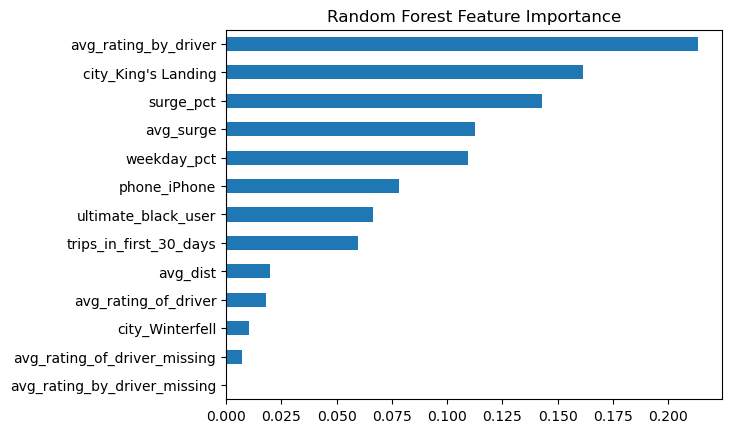

In [91]:
#Lets look at Random Forest Relative Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index = X.columns)
feat_imp.sort_values().plot(kind ='barh')
plt.title("Random Forest Feature Importance")
plt.show()

##### Top predictors :
•	avg_rating_by_driver (~ 0.21)  - Rider's rating from drivers appears to be the strongest overall signal for retention.  
•	city_King's Landing (~ 0.16) - second most important, similar to Logistic Regression feature ranking.  
•	surge_pct (~ 0.14) and avg_surge (~ 0.11) — both surge-related features also seem to have a positive effect on user retention rate. Again, though counterintuitive, this may be because frequent users see surge more often and do not pay much attention to it due to the need.  
•	weekday_pct (~ 0.11) - meaningful importance here despite having a near-zero linear coefficient in Logistic Regression, reinforcing the earlier point that random forest’s predictive value comes from non-linear effects a linear model can't capture.  
##### Moderate Predictors :
•	phone_iPhone (~ 0.08), ultimate_black_user (~ 0.065), trips_in_first_30_days (~ 0.06) — These contribute moderately and still have a meaningful impact on user retention.  
##### Low Impact :
•	avg_dist, avg_rating_of_driver, city_Winterfell, avg_rating_of_driver_missing, avg_rating_by_driver_missing — all have low impact on user retention.

## 1.8 Key Insights<a id='1.8_Key Insights'></a>

##### 1.	Random Forest outperforms Logistic Regression across every metric (accuracy 78% vs. 72%, AUC 0.847 vs. 0.765), indicating the true relationship between rider behavior and retention involves non-linear relationships that a linear model cannot fully capture.  Hence Random Forest or a tree based model is a model of choice for this dataset.
##### 2.	Driver ratings for users and signup city are the strongest predictors in Random Forest model  - Logistic Regression also ranks signup city as the topmost predictor. This means that geography and market driven effects matter. Also, riders with higher average ratings are more likely to be retained, indicating experience quality matters.  
##### 3.	Early engagement also seems to be an important predictor in both models for higher retention. This is something Ultimate should use as an actionable item.  
##### 4.	Users engaging with premium services (Ultimate Black) show higher retention.  
##### 5.	Surge multiplier and weekday usage matter more in Random Forest model. Both have near-zero linear coefficients in Logistic Regression but rank highly in Random Forest importance — suggesting their effect on retention is conditional (may depend on city or frequent service usage).  
##### 6.	Device type also seems to be meaningfully associated with user retention. However, this should be used with caution since it might just be that there are more iPhone users in the market, something Ultimate cannot control for. However, they could evaluate how their app operates on both phone types.
##### 7.	Missing ratings may signal low engagement users and less chances of retention.  
##### 8.	Higher Avg. distance trip users might be more infrequent users more likely to churn or switch service.  

## 1.9 Recommendations<a id='1.9_Recommendations'></a>

##### 1.	Use Random Forest as the operational model — it's more accurate and better balanced across both classes.
##### 2.	Prioritize early trip volume and rating quality as retention levers — since both are positively tied to retention, consider first-30-day engagement incentives (discounts, promotions, more access to premium services, better onboarding) and driver-side service quality initiatives.
##### 3.	Investigate the city/device retention gap operationally — treat low-retention cities (e.g., Astapor) & Android users as flags for service-quality issues (driver supply, app experience) worth a root-cause review. Also, target low activity users.
##### 4.	Don't over-rely on surge-related variables. Use them with caution as a signal of higher usage/engagement.
##### 5.	Work on the rating system and encourage feedback by making it easy & incentivizing providing ratings for both drivers and users.

## 1.10 Limitations & Next Steps<a id='1.10_Limitations_&_Next_Steps'></a>

##### Limitations

1. We have just been provided data on one cohort (January 2014) and it may not generalize to other cohorts.
2. Retention definition is not very precise.
3. Other important features like competition, seasonality etc. have not been captured.
   
##### Next 

1.	Run the model on more cohorts. 
2.	Investigate other tree based models for stronger predictive behavior.
3.	Improve retention definition and see if more features are available.
4.	A/B test changes made to increase retention prior to rolling changes out widely.

In [95]:
#Deleting the dataset as requested.
os.remove('ultimate_data_challenge.json')